#**EVIDENCIA 5**

#**EMAX:**

José Emiliano Díaz Gutiérrez | A01711141

Ximena Cantera Reséndiz       | A01277310

Ma. Fernanda Barba De Los Santos  | A01657868


#**Importar librerías y documentos**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
distribuidores = pd.read_csv('distribuidores_cleaned.csv')
horas = pd.read_csv('horas_cleaned.csv')
ruteo = pd.read_csv('ruteo_cleaned.csv')
mantenimientos = pd.read_csv('mantenimientos_cleaned.csv')
population = pd.read_csv('population_cleaned.csv')
reporte = pd.read_csv('reporte_cleaned.csv')

## **Data Preprocessing and Feature Engineering**

These steps prepare the `mantenimientos` and `reporte` dataframes by creating necessary features and handling missing values, which are essential for generating the subsequent visualizations. Many of these steps were previously defined in deleted cells.

In [ ]:
# 1. Create 'delay_vs_service_interval' and 'overdue_risk' in 'mantenimientos'
mantenimientos['delay_vs_service_interval'] = mantenimientos['ACTUAL'] - mantenimientos['SERVICIO']

# Map status to overdue_risk
status_risk_mapping = {'Cerrada': 0, 'PorVencer': 1, 'EnProceso': 1, 'Abierta': 1, 'Pendiente': 2, 'CerradaFuera': 2}
mantenimientos['overdue_risk'] = mantenimientos['ESTATUS'].map(status_risk_mapping)
mantenimientos['overdue_risk'].fillna(0, inplace=True)


In [ ]:
# 2. Calculate general service status statistics
nobs = len(mantenimientos)
pendiente_fuera_status = ['Pendiente', 'CerradaFuera']

mantenimientos['is_pend_fuera'] = mantenimientos['ESTATUS'].isin(pendiente_fuera_status)
count_pend_fuera = mantenimientos['is_pend_fuera'].sum()
observed_proportion = count_pend_fuera / nobs

status_counts = mantenimientos['ESTATUS'].value_counts()
status_proportions = mantenimientos['ESTATUS'].value_counts(normalize=True)

# Define df_pend_fuera_delay for 'Servicios en Fuga por Distribuidor' plot
df_pend_fuera_delay = mantenimientos[mantenimientos['ESTATUS'].isin(pendiente_fuera_status)].copy()


In [ ]:
# 3. Create 'frecuencia_servicio_df'
frecuencia_servicio_df = mantenimientos.groupby('ALIAS').size().reset_index(name='frecuencia_servicio')


In [ ]:
# 4. Create 'df_unidades_xgb' for 'edad_equipo'
df_unidades_xgb = reporte[['Alias', 'Fecha Alta']].copy()
df_unidades_xgb.rename(columns={'Alias': 'ALIAS'}, inplace=True)
df_unidades_xgb['Fecha Alta'] = pd.to_datetime(df_unidades_xgb['Fecha Alta'], errors='coerce')
current_date = pd.to_datetime('today')
df_unidades_xgb['edad_equipo'] = ((current_date - df_unidades_xgb['Fecha Alta']).dt.days / 365.25).round(2)
df_unidades_xgb.dropna(subset=['edad_equipo'], inplace=True)


In [ ]:
# 5. Calculate 'valor_acumulado_aftermarket' and create 'valor_aftermarket_df'
columnas_valor_aftermarket = ['Cerrados', 'C.Fuera', 'Pendientes']
for col in columnas_valor_aftermarket:
    reporte[col] = pd.to_numeric(reporte[col], errors='coerce')
reporte['valor_acumulado_aftermarket'] = reporte[columnas_valor_aftermarket].fillna(0).sum(axis=1)
valor_aftermarket_df = reporte[['Alias', 'valor_acumulado_aftermarket']].rename(columns={'Alias': 'ALIAS'}).copy()


In [ ]:
# 6. Create 'df_filtered_anova' with 'score_operativo' and 'SEVERITY_LEVEL'
relevant_status = ['Pendiente', 'Cerrado', 'CerradaFuera']
df_filtered_anova = mantenimientos[
    mantenimientos['ESTATUS'].isin(relevant_status)
].copy()

df_filtered_anova = df_filtered_anova.dropna(subset=['ACTUAL', 'HRMTRO', 'SERVICIO', 'ESTATUS'])

df_filtered_anova['score_operativo'] = (
    df_filtered_anova['ACTUAL'] +
    df_filtered_anova['HRMTRO'] +
    df_filtered_anova['SERVICIO']
) / 3

df_filtered_anova['SEVERITY_LEVEL'] = pd.qcut(
    df_filtered_anova['score_operativo'],
    q=3,
    labels=['Low', 'Medium', 'High'],
    duplicates='drop'
)

df_filtered_anova['ESTATUS'] = df_filtered_anova['ESTATUS'].astype('category')
df_filtered_anova['SEVERITY_LEVEL'] = df_filtered_anova['SEVERITY_LEVEL'].astype('category')


In [ ]:
# 7. Create 'df_monetization' and its derived columns (RIT, VAE, score_oportunidad)
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# Aggregate risk metrics by ALIAS
rit_agg_df = mantenimientos.groupby('ALIAS').agg(
    avg_overdue_risk=('overdue_risk', 'mean'),
    avg_delay_vs_service_interval=('delay_vs_service_interval', 'mean')
).reset_index()

# Rename 'VIN (17 CHARACTERS)' to 'NO SERIE' and 'SEVERITY LEVEL' to 'SEVERITY_LEVEL' in population
df_population_xgb = population.rename(columns={'VIN (17 CHARACTERS)': 'NO SERIE', 'SEVERITY LEVEL': 'SEVERITY_LEVEL'}).copy()

# Get severity level per ALIAS
df_maint_with_severity = pd.merge(mantenimientos, df_population_xgb[['NO SERIE', 'SEVERITY_LEVEL']], on='NO SERIE', how='left')
severity_per_alias = df_maint_with_severity.groupby('ALIAS')['SEVERITY_LEVEL'].agg(lambda x: x.mode()[0] if not x.mode().empty else np.nan).reset_index()

# Consolidate all features at the unit level
df_monetization = pd.merge(frecuencia_servicio_df, valor_aftermarket_df, on='ALIAS', how='left')
df_monetization = pd.merge(df_monetization, df_unidades_xgb[['ALIAS', 'edad_equipo']], on='ALIAS', how='left')
df_monetization = pd.merge(df_monetization, rit_agg_df, on='ALIAS', how='left')
df_monetization = pd.merge(df_monetization, severity_per_alias, on='ALIAS', how='left')

# Normalize RIT and VAE
scaler = MinMaxScaler()
df_monetization['RIT_normalizado'] = scaler.fit_transform(df_monetization[['avg_overdue_risk']])
df_monetization['VAE_normalizado'] = scaler.fit_transform(df_monetization[['valor_acumulado_aftermarket']])

# Calculate score_oportunidad
df_monetization['score_oportunidad'] = df_monetization['RIT_normalizado'] * df_monetization['VAE_normalizado']


---

---------

##**Diagramas de sugerencia página**


## **Distribuidor**

### **Historial de Mantenimiento por Unidad**

Esta gráfica visualiza el historial de mantenimiento para una unidad específica, mostrando las horas actuales ('ACTUAL') y las horas de servicio ('SERVICIO') a lo largo del tiempo, junto con el estado de cada evento de mantenimiento. Esto permite observar tendencias, identificar retrasos en el servicio y comprender el ciclo de vida del mantenimiento de una unidad.

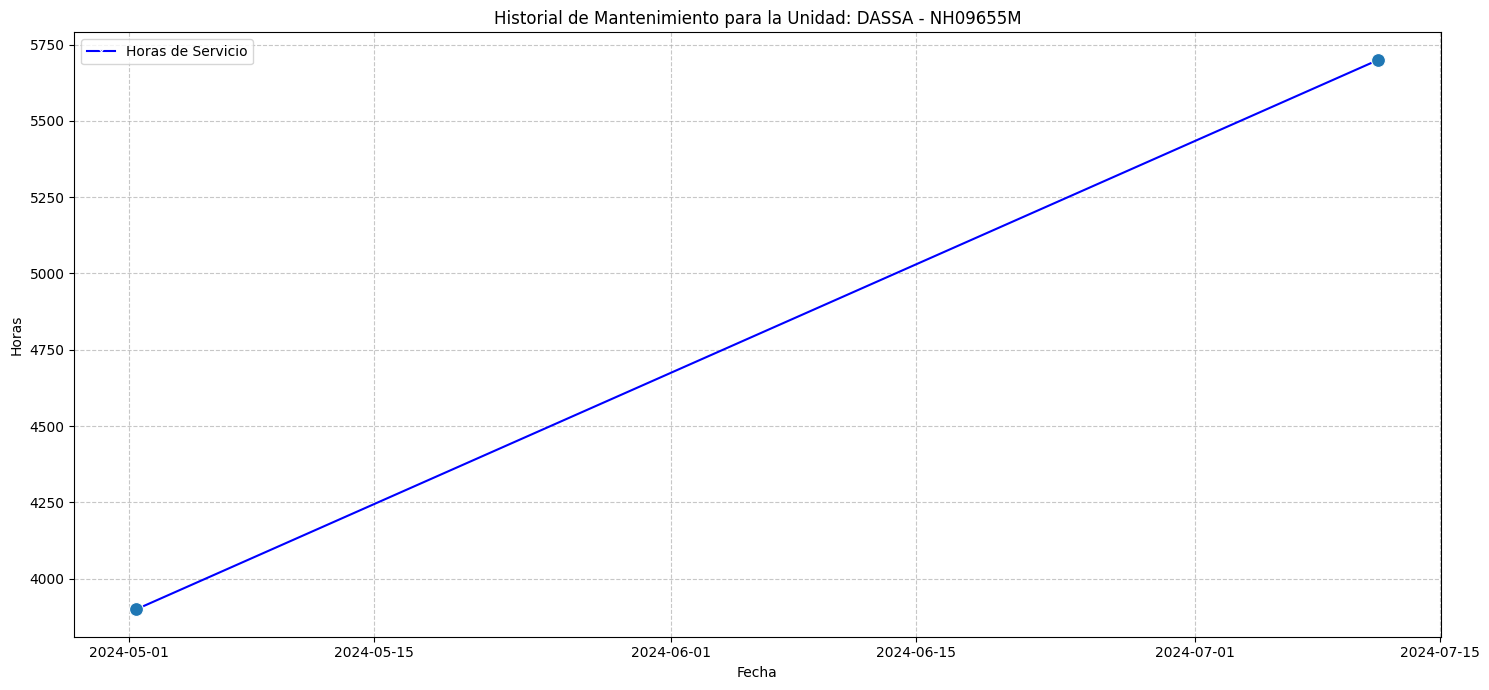

In [ ]:
unit_alias = 'DASSA - NH09655M' # Se busca por ALIAS

df_unit_history = mantenimientos[mantenimientos['ALIAS'] == unit_alias].copy()

df_unit_history['FECHA'] = pd.to_datetime(df_unit_history['FECHA'], errors='coerce')
df_unit_history = df_unit_history.sort_values('FECHA').dropna(subset=['FECHA'])

plt.figure(figsize=(15, 7))

sns.lineplot(x='FECHA', y='SERVICIO', data=df_unit_history, marker='x', label='Horas de Servicio', color='blue')

sns.scatterplot(x='FECHA', y='SERVICIO', data=df_unit_history, s=100, zorder=5)

plt.title(f'Historial de Mantenimiento para la Unidad: {unit_alias}')
plt.xlabel('Fecha')
plt.ylabel('Horas')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

### **Alerta Roja para Unidades Críticas**

Esta visualización identifica las unidades que cumplen con los criterios de "alerta roja": estatus 'Pendiente' o 'CerradaFuera', un `overdue_risk` alto (2.0) y un nivel de severidad 'High' (derivado del `score_operativo`). Esto apoya la "Crear alerta roja para unidades críticas".

Número de unidades en 'Alerta Roja': 1366


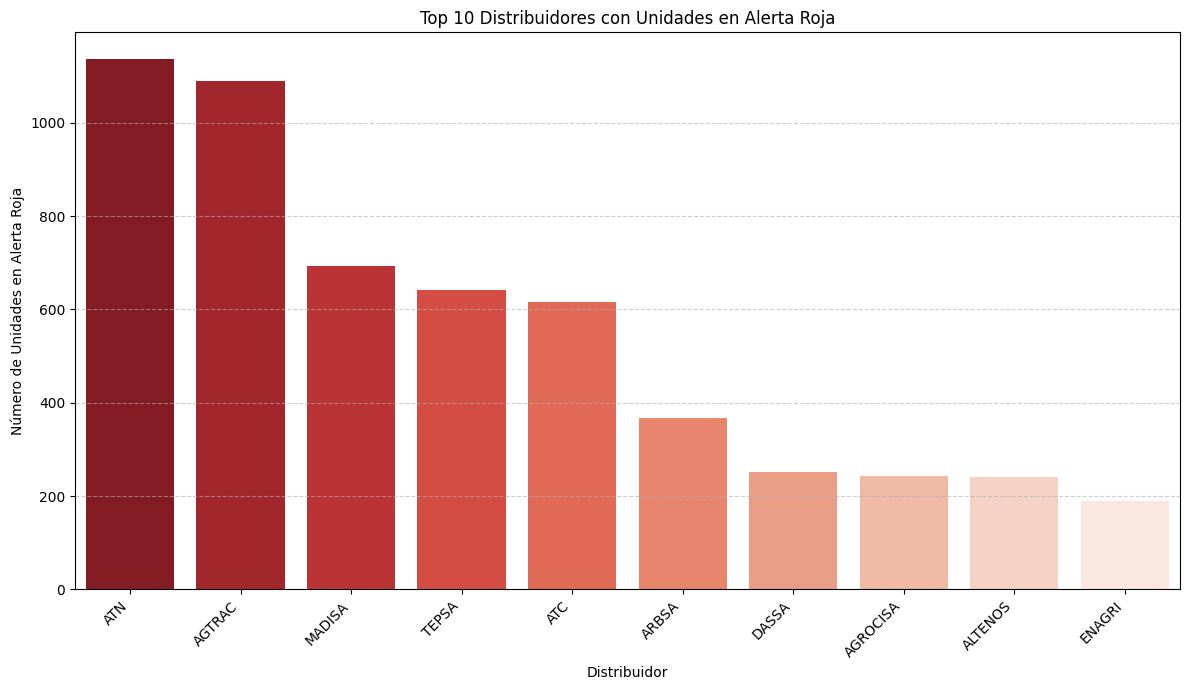

In [ ]:
# Identificar las unidades com 'red alert' usando df_filtered_anova
red_alert_units = df_filtered_anova[
    (df_filtered_anova['ESTATUS'].isin(['Pendiente', 'CerradaFuera'])) &
    (df_filtered_anova['overdue_risk'] == 2.0) &
    (df_filtered_anova['SEVERITY_LEVEL'] == 'High')
]

num_red_alert = red_alert_units['ALIAS'].nunique()
print(f"Número de unidades en 'Alerta Roja': {num_red_alert}")

red_alert_dist = red_alert_units.groupby('DISTRIBUIDOR').size().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 7))
sns.barplot(x=red_alert_dist.index, y=red_alert_dist.values, palette='Reds_r')
plt.title('Top 10 Distribuidores con Unidades en Alerta Roja')
plt.xlabel('Distribuidor')
plt.ylabel('Número de Unidades en Alerta Roja')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### **Ranking Comercial de Unidades con Mayor Oportunidad**

Para "Hacer un ranking comercial de unidades con mayor oportunidad", visualizamos las unidades con el `score_oportunidad` más alto.

In [ ]:
red_alert_units = df_filtered_anova[
    (df_filtered_anova['ESTATUS'].isin(['Pendiente', 'CerradaFuera'])) &
    (df_filtered_anova['overdue_risk'] == 2.0) &
    (df_filtered_anova['SEVERITY_LEVEL'] == 'High')
]

red_alert_units_per_dist = red_alert_units.groupby('DISTRIBUIDOR')['ALIAS'].nunique().reset_index()
red_alert_units_per_dist.rename(columns={'ALIAS': 'Unidades en Alerta Roja'}, inplace=True)

total_units_per_dist = mantenimientos.groupby('DISTRIBUIDOR')['ALIAS'].nunique().reset_index()
total_units_per_dist.rename(columns={'ALIAS': 'Total Unidades'}, inplace=True)

red_alert_summary = pd.merge(red_alert_units_per_dist, total_units_per_dist, on='DISTRIBUIDOR', how='left')
red_alert_summary['Porcentaje en Alerta Roja'] = (red_alert_summary['Unidades en Alerta Roja'] / red_alert_summary['Total Unidades']) * 100

red_alert_summary_sorted = red_alert_summary.sort_values(by='Unidades en Alerta Roja', ascending=False)

display(red_alert_summary_sorted.head(10).round(2))

,DISTRIBUIDOR,Unidades en Alerta Roja,Total Unidades,Porcentaje en Alerta Roja
4,AGTRAC,252,1159,21.74
8,ATN,202,637,31.71
19,MADISA,158,895,17.65
24,TEPSA,152,917,16.58
7,ATC,117,371,31.54
12,DASSA,83,323,25.70
6,ARBSA,77,353,21.81
0,AGROCISA,69,463,14.90
5,ALTENOS,53,486,10.91
16,ENAGRI,52,326,15.95


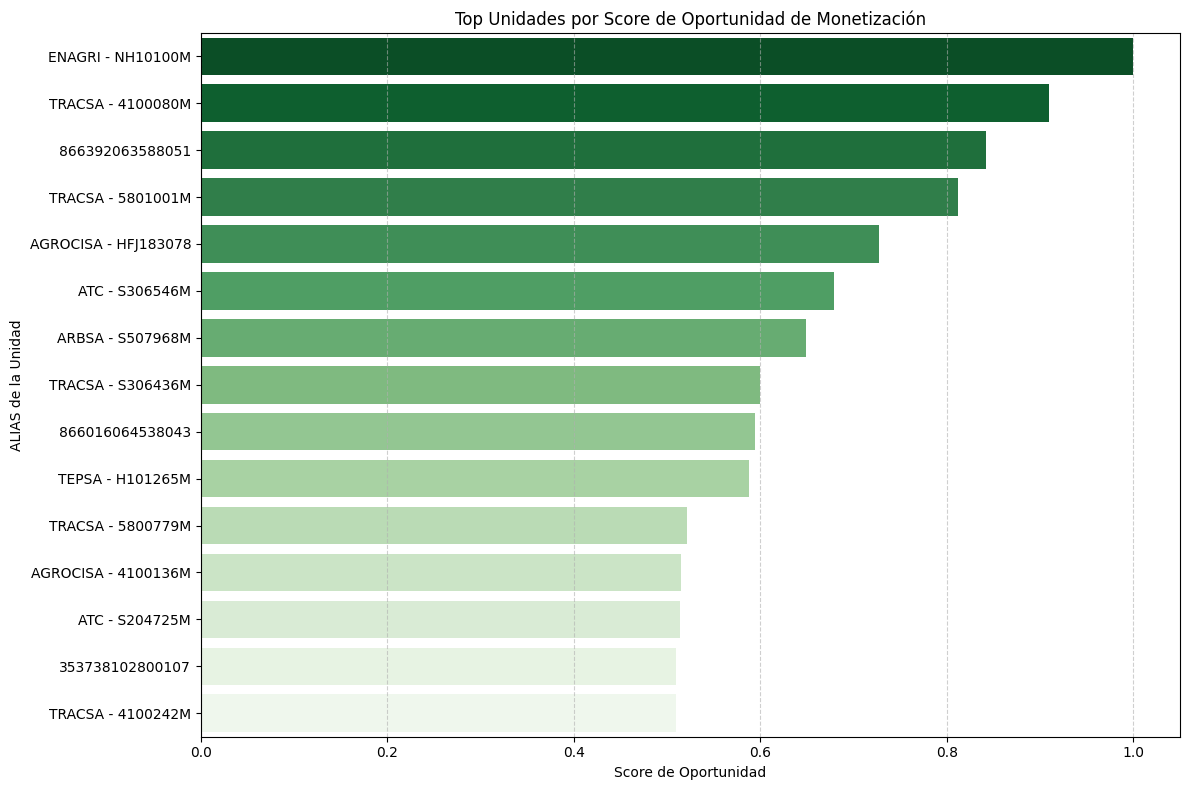

In [ ]:
top_opportunity_units = df_monetization.sort_values(by='score_oportunidad', ascending=False).head(15)

plt.figure(figsize=(12, 8))
sns.barplot(x='score_oportunidad', y='ALIAS', data=top_opportunity_units, palette='Greens_r')
plt.title('Top Unidades por Score de Oportunidad de Monetización')
plt.xlabel('Score de Oportunidad')
plt.ylabel('ALIAS de la Unidad')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

## **Monetización**


### **Valor Acumulado de Aftermarket por Distribuidor**

Esta visualización presenta el valor acumulado total de aftermarket generado por las unidades de cada distribuidor. Es crucial para identificar a los distribuidores con mayor contribución económica en términos de servicios y piezas, y para enfocar las estrategias de crecimiento en el aftermarket.

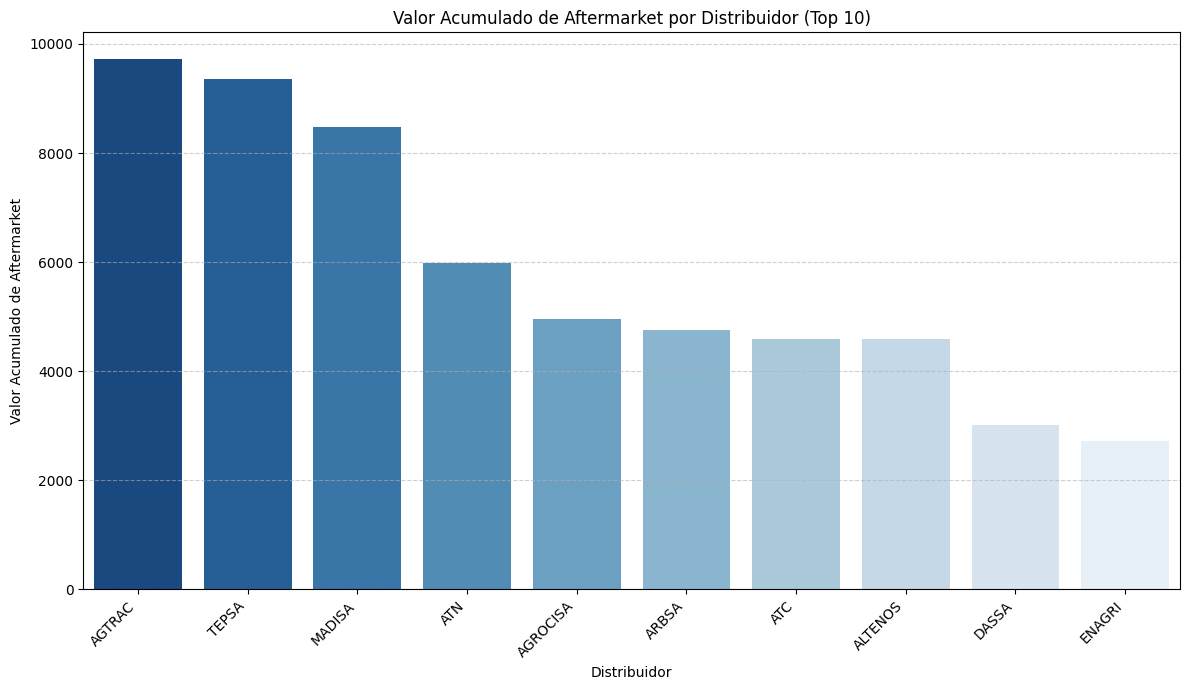

,DISTRIBUIDOR,valor_acumulado_aftermarket
0,AGTRAC,9726.0
1,TEPSA,9358.0
2,MADISA,8481.0
3,ATN,5988.0
4,AGROCISA,4951.0
5,ARBSA,4751.0
6,ATC,4594.0
7,ALTENOS,4590.0
8,DASSA,3018.0
9,ENAGRI,2717.0


In [ ]:
# Merge df_monetization con ALIAS-DISTRIBUIDOR unicos de mantenimientos
alias_dist_map = mantenimientos[['ALIAS', 'DISTRIBUIDOR']].drop_duplicates()
df_monetization_with_dist = pd.merge(df_monetization, alias_dist_map, on='ALIAS', how='left')

# Agregar total del valor_acumulado_aftermarket por distribuidor
dist_total_aftermarket = df_monetization_with_dist.groupby('DISTRIBUIDOR')['valor_acumulado_aftermarket'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 7))
sns.barplot(x=dist_total_aftermarket.index, y=dist_total_aftermarket.values, palette='Blues_r')
plt.title('Valor Acumulado de Aftermarket por Distribuidor (Top 10)')
plt.xlabel('Distribuidor')
plt.ylabel('Valor Acumulado de Aftermarket')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

display(dist_total_aftermarket.reset_index())

## **Proyección**

En esta sección, se presentan proyecciones y análisis de tendencias para anticipar comportamientos futuros. Estas visualizaciones ayudan a identificar oportunidades o riesgos emergentes.

In [ ]:
import statsmodels.api as sm

# Proporción para 'Cerrada'
count_cerrada = mantenimientos[mantenimientos['ESTATUS'] == 'Cerrada'].shape[0]
prop_cerrada = count_cerrada / nobs
ci_low_cerrada, ci_upp_cerrada = sm.stats.proportion_confint(count_cerrada, nobs, alpha=0.05, method='normal')

proportions_data = {
    'Estatus de Servicio': ['Pendiente o CerradaFuera', 'Cerrada'],
    'Proporción': [observed_proportion, prop_cerrada],
    'IC 95% Inferior': [ci_low, ci_low_cerrada],
    'IC 95% Superior': [ci_upp, ci_upp_cerrada]
}

df_proportions_analysis = pd.DataFrame(proportions_data)

print("Tabla: Análisis de Proporciones de Estatus de Servicio")
display(df_proportions_analysis)

Tabla: Análisis de Proporciones de Estatus de Servicio


,Estatus de Servicio,Proporción,IC 95% Inferior,IC 95% Superior
0,Pendiente o CerradaFuera,0.764506,0.759123,0.769889
1,Cerrada,0.211027,0.205850,0.216203


## Dash Visualizations for Suggestion Page Diagrams

In [ ]:
#!pip install dash==2.14.2 dash_core_components==2.0.0 dash_html_components==2.0.0

In [ ]:
import dash
import dash_core_components as dcc
import dash_html_components as html
import plotly.express as px
import plotly.graph_objects as go

# --- 1. Historial de Mantenimiento por Unidad---
unit_alias = 'DASSA - NH09655M' # Se busca por ALIAS
df_unit_history = mantenimientos[mantenimientos['ALIAS'] == unit_alias].copy()
df_unit_history['FECHA'] = pd.to_datetime(df_unit_history['FECHA'], errors='coerce')
df_unit_history = df_unit_history.sort_values('FECHA').dropna(subset=['FECHA'])

fig_history = go.Figure()
fig_history.add_trace(go.Scatter(
    x=df_unit_history['FECHA'],
    y=df_unit_history['SERVICIO'],
    mode='lines+markers',
    name='Horas de Servicio',
    hovertemplate='Fecha: %{x}<br>Horas de Servicio: %{y}<extra></extra>'
))

fig_history.update_layout(
    title=f'Historial de Mantenimiento para la Unidad: {unit_alias}',
    xaxis_title='Fecha',
    yaxis_title='Horas',
    hovermode='x unified',
    width=1000,
    height=600
)

# --- 2. Alerta Roja para Unidades Críticas
red_alert_units = df_filtered_anova[
    (df_filtered_anova['ESTATUS'].isin(['Pendiente', 'CerradaFuera'])) &
    (df_filtered_anova['overdue_risk'] == 2.0) &
    (df_filtered_anova['SEVERITY_LEVEL'] == 'High')
]
red_alert_dist = red_alert_units.groupby('DISTRIBUIDOR').size().sort_values(ascending=False).head(10).reset_index(name='count')

fig_red_alert = px.bar(red_alert_dist,
                       x='DISTRIBUIDOR',
                       y='count',
                       title='Top 10 Distribuidores con Unidades en Alerta Roja',
                       labels={'count': 'Número de Unidades en Alerta Roja'},
                       color='count',
                       color_continuous_scale='Reds')
fig_red_alert.update_xaxes(categoryorder='total descending')
fig_red_alert.update_layout(
    width=1000,
    height=600
)

# --- 3. Ranking Comercial de Unidades con Mayor Oportunidad---
top_opportunity_units = df_monetization.sort_values(by='score_oportunidad', ascending=False).head(15)

fig_opportunity = px.bar(top_opportunity_units,
                        x='score_oportunidad',
                        y='ALIAS',
                        orientation='h',
                        title='Top Unidades por Score de Oportunidad de Monetización',
                        color='score_oportunidad',
                        color_continuous_scale='Greens')
fig_opportunity.update_yaxes(categoryorder='total ascending')
fig_opportunity.update_layout(
    width=1000,
    height=600
)

# --- 4. Valor Acumulado de Aftermarket por Distribuidor---
alias_dist_map = mantenimientos[['ALIAS', 'DISTRIBUIDOR']].drop_duplicates()
df_monetization_with_dist = pd.merge(df_monetization, alias_dist_map, on='ALIAS', how='left')
dist_total_aftermarket = df_monetization_with_dist.groupby('DISTRIBUIDOR')['valor_acumulado_aftermarket'].sum().sort_values(ascending=False).head(10).reset_index()

fig_aftermarket = px.bar(dist_total_aftermarket,
                        x='DISTRIBUIDOR',
                        y='valor_acumulado_aftermarket',
                        title='Valor Acumulado de Aftermarket por Distribuidor (Top 10)',
                        color='valor_acumulado_aftermarket',
                        color_continuous_scale='Blues')
fig_aftermarket.update_xaxes(categoryorder='total descending')
fig_aftermarket.update_layout(
    width=1000,
    height=600
)

# --- 5. Distribución de Retraso en Horas
fig_delay_distribution = px.histogram(mantenimientos, x='delay_vs_service_interval', nbins=50,
                                     title='Distribución de Retraso en Horas de Mantenimiento',
                                     labels={'delay_vs_service_interval': 'Retraso en Horas'},
                                     color_discrete_sequence=px.colors.qualitative.Plotly)
fig_delay_distribution.update_layout(width=1000, height=600)

# --- 6. Servicios en Fuga por Distribuidor
leakage_services_by_dist = df_pend_fuera_delay.groupby('DISTRIBUIDOR').size().sort_values(ascending=False).reset_index(name='count')

fig_leakage_services = px.bar(
    leakage_services_by_dist,
    x='DISTRIBUIDOR',
    y='count',
    title='Servicios en Fuga por Distribuidor',
    labels={'count': 'Número de Servicios en Fuga'},
    color='count',
    color_continuous_scale='Reds'
)
fig_leakage_services.update_xaxes(categoryorder='total descending')
fig_leakage_services.update_layout(width=1000, height=600)

# --- 7. Proporción de Estatus de Servicio
status_color_map = {
    'Cerrada': '#C7F4C4',       # Verde claro
    'CerradaFuera': '#A4B5FA',  # Azul claro
    'Pendiente': '#FF6B6B',     # Rojo claro
    'PorVencer': '#8B0000',     # Rojo oscuro
    'EnProceso': '#800080',     # Morado
    'Abierta': '#DDA0DD',       # Morado claro
    'Desconocido': '#D3D3D3'    # Gris claro
}
fig_status_proportions = px.pie(names=status_proportions.index, values=status_proportions.values,
                                  title='Proporción de Estatus de Servicio',
                                  color=status_proportions.index,
                                  color_discrete_map=status_color_map)
fig_status_proportions.update_layout(width=1000, height=600)

# --- 8. Matriz de Riesgo Operativo por Distribuidor
red_alert_units_per_dist = red_alert_units.groupby('DISTRIBUIDOR')['ALIAS'].nunique().reset_index()
red_alert_units_per_dist.rename(columns={'ALIAS': 'Unidades en Alerta Roja'}, inplace=True)
total_units_per_dist = mantenimientos.groupby('DISTRIBUIDOR')['ALIAS'].nunique().reset_index()
total_units_per_dist.rename(columns={'ALIAS': 'Total Unidades'}, inplace=True)
red_alert_summary = pd.merge(red_alert_units_per_dist, total_units_per_dist, on='DISTRIBUIDOR', how='left')
red_alert_summary['Porcentaje en Alerta Roja'] = (red_alert_summary['Unidades en Alerta Roja'] / red_alert_summary['Total Unidades']) * 100

fig_risk_matrix = px.scatter(red_alert_summary,
                             x='Porcentaje en Alerta Roja',
                             y='Unidades en Alerta Roja',
                             size='Total Unidades',
                             color='DISTRIBUIDOR',
                             hover_name='DISTRIBUIDOR',
                             title='Matriz de Riesgo Operativo por Distribuidor',
                             labels={
                                 'Porcentaje en Alerta Roja': 'Porcentaje de Unidades en Alerta Roja',
                                 'Unidades en Alerta Roja': 'Número de Unidades en Alerta Roja'
                             },
                             size_max=60)

fig_risk_matrix.update_layout(
    width=1000,
    height=600,
    showlegend=False
)

# --- 9. Top 10 Unidades Críticas por Antigüedad de Alerta
# Filtrar mantenimientos con estatus 'Pendiente' o 'CerradaFuera'
df_alerts = mantenimientos[mantenimientos['ESTATUS'].isin(['Pendiente', 'CerradaFuera'])].copy()

# Convertir 'FECHA' a datetime
df_alerts['FECHA'] = pd.to_datetime(df_alerts['FECHA'], errors='coerce')
df_alerts.dropna(subset=['FECHA'], inplace=True)

# Calcular la antigüedad de la alerta (días desde la fecha de la alerta hasta today)
current_date = pd.to_datetime('today')
df_alerts['antiguedad_alerta'] = (current_date - df_alerts['FECHA']).dt.days

# Obtener la alerta más antigua por cada ALIAS
oldest_alerts_per_unit = df_alerts.groupby('ALIAS')['antiguedad_alerta'].min().reset_index()

# Unir con el estatus original para asegurar que solo consideramos alertas
oldest_alerts_per_unit = pd.merge(oldest_alerts_per_unit, df_alerts[['ALIAS', 'ESTATUS']].drop_duplicates(), on='ALIAS', how='left')

# Ordenar por antigüedad de alerta y seleccionar el top 10
top_10_oldest_alerts = oldest_alerts_per_unit.sort_values(by='antiguedad_alerta', ascending=False).head(10)

fig_oldest_alerts = px.bar(
    top_10_oldest_alerts,
    x='ALIAS',
    y='antiguedad_alerta',
    title='Top 10 Unidades Críticas por Antigüedad de Alerta (Días)',
    labels={'antiguedad_alerta': 'Antigüedad de la Alerta (Días)', 'ALIAS': 'Unidad ALIAS'},
    color='antiguedad_alerta',
    color_continuous_scale='Oranges_r' # Scale from light to dark orange for older alerts
)

fig_oldest_alerts.update_xaxes(categoryorder='total descending')
fig_oldest_alerts.update_layout(
    width=1000,
    height=600
)

# --- 10. Curva de Pareto: % Unidades vs % Potencial Económico
# Calcular el total del score de oportunidad
total_score = df_monetization['score_oportunidad'].sum()

# Ordenar el DataFrame por score_oportunidad de forma descendente
df_pareto = df_monetization.sort_values(by='score_oportunidad', ascending=False).reset_index(drop=True)

# Calcular el porcentaje acumulado de score_oportunidad
df_pareto['cumulative_score_pct'] = (df_pareto['score_oportunidad'].cumsum() / total_score) * 100

# Calcular el porcentaje acumulado de unidades
df_pareto['cumulative_units_pct'] = (df_pareto.index + 1) / len(df_pareto) * 100

# Crear la figura del gráfico de Pareto
fig_pareto = go.Figure()

# Añadir la barra para el score_oportunidad individual (opcional, para visualización)
fig_pareto.add_trace(go.Bar(
    x=df_pareto['cumulative_units_pct'],
    y=df_pareto['score_oportunidad'],
    name='Score de Oportunidad (Individual)',
    marker_color='lightblue',
    yaxis='y1'
))

# Añadir la línea para el porcentaje acumulado de score_oportunidad
fig_pareto.add_trace(go.Scatter(
    x=df_pareto['cumulative_units_pct'],
    y=df_pareto['cumulative_score_pct'],
    mode='lines+markers',
    name='Porcentaje Acumulado de Score de Oportunidad',
    line=dict(color='red', width=2),
    yaxis='y2'
))

fig_pareto.update_layout(
    title='Curva de Pareto: % Unidades vs % Potencial Económico',
    xaxis_title='Porcentaje Acumulado de Unidades',
    yaxis_title='Score de Oportunidad (Individual)',
    yaxis2=dict(
        title='Porcentaje Acumulado de Score de Oportunidad',
        overlaying='y',
        side='right',
        range=[0, 100]  # Asegura que el eje Y2 vaya de 0 a 100%
    ),
    hovermode='x unified',
    width=1000,
    height=600,
    legend=dict(x=0.01, y=0.99)
)

# --- 11. Score de Oportunidad por Componente (Top 15 Unidades)
top_units_by_opportunity = df_monetization.sort_values(by='score_oportunidad', ascending=False).head(15)

# Prepare data for stacked bar chart
df_score_components = top_units_by_opportunity[['ALIAS', 'RIT_normalizado', 'VAE_normalizado']].melt(id_vars='ALIAS', var_name='Componente', value_name='Valor Normalizado')

fig_opportunity_components = px.bar(
    df_score_components,
    x='ALIAS',
    y='Valor Normalizado',
    color='Componente',
    title='Score de Oportunidad por Componente (Top 15 Unidades)',
    labels={
        'ALIAS': 'Unidad ALIAS',
        'Valor Normalizado': 'Valor Normalizado',
        'Componente': 'Componente de Score'
    },
    height=600,
    width=1000,
    color_discrete_map={'RIT_normalizado': 'rgb(255, 127, 14)', 'VAE_normalizado': 'rgb(31, 119, 180)'}
)

fig_opportunity_components.update_layout(barmode='group')

In [ ]:
fig_delay_distribution = px.histogram(mantenimientos, x='delay_vs_service_interval', nbins=50,
                                     title='Distribución de Retraso en Horas de Mantenimiento',
                                     labels={'delay_vs_service_interval': 'Retraso en Horas'},
                                     color_discrete_sequence=px.colors.qualitative.Plotly)
fig_delay_distribution.update_layout(width=1000, height=600)

In [ ]:
leakage_services_by_dist = df_pend_fuera_delay.groupby('DISTRIBUIDOR').size().sort_values(ascending=False).reset_index(name='count')

fig_leakage_services = px.bar(
    leakage_services_by_dist,
    x='DISTRIBUIDOR',
    y='count',
    title='Servicios en Fuga por Distribuidor',
    labels={'count': 'Número de Servicios en Fuga'},
    color='count',
    color_continuous_scale='Reds'
)
fig_leakage_services.update_xaxes(categoryorder='total descending')


### Dash Application Layout

In [ ]:
app.layout = html.Div(children=[
    html.H1(children='Suggestion Page Diagrams - Dash App'),

    html.H3(children='Historial de Mantenimiento por Unidad'),
    dcc.Graph(
        id='maintenance-history-graph',
        figure=fig_history
    ),

    html.H3(children='Alerta Roja para Unidades Críticas'),
    dcc.Graph(
        id='red-alert-graph',
        figure=fig_red_alert
    ),

    html.H3(children='Ranking Comercial de Unidades con Mayor Oportunidad'),
    dcc.Graph(
        id='opportunity-ranking-graph',
        figure=fig_opportunity
    ),

    html.H3(children='Valor Acumulado de Aftermarket por Distribuidor'),
    dcc.Graph(
        id='aftermarket-value-graph',
        figure=fig_aftermarket
    ),

    html.H3(children='Distribución de Retraso en Horas'),
    dcc.Graph(
        id='delay-distribution-graph',
        figure=fig_delay_distribution
    )
])

if __name__ == '__main__':
    app.run_server(mode='inline', port=8050)

<IPython.core.display.Javascript object>

In [ ]:
app = dash.Dash(__name__)

app.layout = html.Div(children=[
    html.H1(children='Suggestion Page Diagrams - Dash App'),

    html.H3(children='1. Maintenance History per Unit'),
    dcc.Graph(
        id='maintenance-history-graph',
        figure=fig_history
    ),

    html.H3(children='2. Top 10 Distributors with Red Alert Critical Units'),
    dcc.Graph(
        id='red-alert-graph',
        figure=fig_red_alert
    ),

    html.H3(children='3. Top Units by Monetization Opportunity Score'),
    dcc.Graph(
        id='opportunity-ranking-graph',
        figure=fig_opportunity
    ),

    html.H3(children='4. Top 10 Distributors by Accumulated Aftermarket Value'),
    dcc.Graph(
        id='aftermarket-value-graph',
        figure=fig_aftermarket
    ),

    html.H3(children='5. Distribution of Maintenance Delay in Hours'),
    dcc.Graph(
        id='delay-distribution-graph',
        figure=fig_delay_distribution
    ),

    html.H3(children='6. Leakage Services by Distributor'),
    dcc.Graph(
        id='leakage-services-graph',
        figure=fig_leakage_services
    ),

    html.H3(children='7. Proportion of Service Status'),
    dcc.Graph(
        id='status-proportions-graph',
        figure=fig_status_proportions
    ),

    html.H3(children='8. Operational Risk Matrix per Distributor'),
    dcc.Graph(
        id='risk-matrix-graph',
        figure=fig_risk_matrix
    ),

    html.H3(children='9. Top 10 Critical Units by Alert Age'),
    dcc.Graph(
        id='oldest-alerts-graph',
        figure=fig_oldest_alerts
    ),

    html.H3(children='10. Pareto Curve: % Units vs % Economic Potential'),
    dcc.Graph(
        id='pareto-curve-graph',
        figure=fig_pareto
    ),

    html.H3(children='11. Opportunity Score by Variable (Top 15 Units)'),
    dcc.Graph(
        id='opportunity-components-graph',
        figure=fig_opportunity_components
    )
])

if __name__ == '__main__':
    app.run_server(mode='inline', port=8050)

<IPython.core.display.Javascript object>

### Matriz de Riesgo Operativo por Distribuidor

### Top 10 Unidades Críticas por Antigüedad de Alerta

Esta visualización muestra las 10 unidades con las alertas de mantenimiento 'Pendiente' o 'CerradaFuera' más antiguas. Ayuda a identificar las unidades que requieren atención urgente debido a la prolongada duración de su estado de alerta.

In [ ]:
app.layout.children.extend([
    html.H3(children='Curva de Pareto: % Unidades vs % Potencial Económico'),
    dcc.Graph(
        id='pareto-curve-graph',
        figure=fig_pareto
    )
])

### Score de Oportunidad por Variable

Esta gráfica desglosa el `score_oportunidad` para las unidades con mayor potencial, mostrando la contribución individual del `RIT_normalizado` (Riesgo de Intervención Técnica) y el `VAE_normalizado` (Valor Económico de Aftermarket). Permite entender qué factor impulsa la oportunidad en cada unidad.

In [ ]:
app.layout.children.extend([
    html.H3(children='Score de Oportunidad por Componente (Top 15 Unidades)'),
    dcc.Graph(
        id='opportunity-components-graph',
        figure=fig_opportunity_components
    )
])

if __name__ == '__main__':
    app.run_server(mode='inline', port=8050)

<IPython.core.display.Javascript object>